In [31]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/Users/milanmanoj/Documents/My Projects/Cross Channel Media Inteligence/data/raw/media_spends.csv')

In [32]:
df.shape

(3051, 10)

In [33]:
print(df.columns.tolist())

['Division', 'Calendar_Week', 'Paid_Views', 'Organic_Views', 'Google_Impressions', 'Email_Impressions', 'Facebook_Impressions', 'Affiliate_Impressions', 'Overall_Views', 'Sales']


In [34]:
df.head()

,Division,Calendar_Week,Paid_Views,Organic_Views,Google_Impressions,Email_Impressions,Facebook_Impressions,Affiliate_Impressions,Overall_Views,Sales
0,A,1/6/2018,392,422,408,349895.0107,73580,12072,682,59417
1,A,1/13/2018,787,904,110,506270.2176,11804,9499,853,56806
2,A,1/20/2018,81,970,742,430042.1538,52232,17048,759,48715
3,A,1/27/2018,25,575,65,417745.6658,78640,10207,942,72047
4,A,2/3/2018,565,284,295,408505.8012,40561,5834,658,56235


In [35]:
df.dtypes

Division                  object
Calendar_Week             object
Paid_Views                 int64
Organic_Views              int64
Google_Impressions         int64
Email_Impressions        float64
Facebook_Impressions       int64
Affiliate_Impressions      int64
Overall_Views              int64
Sales                      int64
dtype: object

In [36]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [37]:
df['calendar_week'] = pd.to_datetime(df['calendar_week'])

In [38]:
df = df.sort_values(['division', 'calendar_week']).reset_index(drop=True)

In [39]:
print(f"Shape: {df.shape}")

Shape: (3051, 10)


In [40]:
print(f"Columns: {df.columns.tolist()}")

Columns: ['division', 'calendar_week', 'paid_views', 'organic_views', 'google_impressions', 'email_impressions', 'facebook_impressions', 'affiliate_impressions', 'overall_views', 'sales']


In [41]:
print(f"Divisions: {df['division'].unique()}")

Divisions: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [42]:
print(f"Date range: {df['calendar_week'].min()} → {df['calendar_week'].max()}")

Date range: 2018-01-06 00:00:00 → 2020-02-29 00:00:00


In [43]:
df.head()

,division,calendar_week,paid_views,organic_views,google_impressions,email_impressions,facebook_impressions,affiliate_impressions,overall_views,sales
0,A,2018-01-06,392,422,408,349895.0107,73580,12072,682,59417
1,A,2018-01-13,787,904,110,506270.2176,11804,9499,853,56806
2,A,2018-01-20,81,970,742,430042.1538,52232,17048,759,48715
3,A,2018-01-27,25,575,65,417745.6658,78640,10207,942,72047
4,A,2018-02-03,565,284,295,408505.8012,40561,5834,658,56235


In [44]:
df.dtypes

division                         object
calendar_week            datetime64[ns]
paid_views                        int64
organic_views                     int64
google_impressions                int64
email_impressions               float64
facebook_impressions              int64
affiliate_impressions             int64
overall_views                     int64
sales                             int64
dtype: object

In [45]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())

=== MISSING VALUES ===
division                 0
calendar_week            0
paid_views               0
organic_views            0
google_impressions       0
email_impressions        0
facebook_impressions     0
affiliate_impressions    0
overall_views            0
sales                    0
dtype: int64


In [46]:
dup_count = df.duplicated().sum()
print(f"\nDuplicate rows: {dup_count}")
df.drop_duplicates(inplace=True)


Duplicate rows: 0


In [47]:
dup_period = df.duplicated(subset=['division', 'calendar_week']).sum()
print(f"Duplicate (Division + Week) entries: {dup_period}")

Duplicate (Division + Week) entries: 113


In [48]:
os.makedirs('/Users/milanmanoj/Documents/My Projects/Cross Channel Media Inteligence/data/processed', exist_ok=True)
os.makedirs('/Users/milanmanoj/Documents/My Projects/Cross Channel Media Inteligence/outputs/reports', exist_ok=True)

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("=== OUTLIER DETECTION (IQR) ===")
outlier_log = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_log.append({
        'column': col,
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'outlier_count': outlier_count,
        'outlier_pct': round(outlier_count / len(df) * 100, 2)
    })
    print(f"{col}: {outlier_count} outliers ({round(outlier_count/len(df)*100,1)}%)")

# Data quality report
quality_report = pd.DataFrame([{
    'column': col,
    'missing_count': df[col].isnull().sum(),
    'fill_rate_pct': round((1 - df[col].isnull().sum()/len(df))*100, 2),
    'min': round(df[col].min(), 2),
    'max': round(df[col].max(), 2),
    'mean': round(df[col].mean(), 2),
    'median': round(df[col].median(), 2),
    'std': round(df[col].std(), 2),
    'outlier_count': next(o['outlier_count'] for o in outlier_log if o['column'] == col)
} for col in numeric_cols])

quality_report.to_csv('/Users/milanmanoj/Documents/My Projects/Cross Channel Media Inteligence/outputs/reports/data_quality_report.csv', index=False)
df.to_csv('/Users/milanmanoj/Documents/My Projects/Cross Channel Media Inteligence/data/processed/media_spends_clean.csv', index=False)

print(f"\nClean data saved: {df.shape[0]} rows × {df.shape[1]} columns")
print("Data quality report saved.")
print("\n✓ Phase 1 complete.")

=== OUTLIER DETECTION (IQR) ===
paid_views: 295 outliers (9.7%)
organic_views: 254 outliers (8.3%)
google_impressions: 286 outliers (9.4%)
email_impressions: 166 outliers (5.4%)
facebook_impressions: 305 outliers (10.0%)
affiliate_impressions: 255 outliers (8.4%)
overall_views: 250 outliers (8.2%)
sales: 286 outliers (9.4%)

Clean data saved: 3051 rows × 10 columns
Data quality report saved.

✓ Phase 1 complete.


In [49]:
df = pd.read_csv('/Users/milanmanoj/Documents/My Projects/Cross Channel Media Inteligence/data/processed/media_spends_clean.csv')
df['calendar_week'] = pd.to_datetime(df['calendar_week'])
df = df.sort_values(['division', 'calendar_week']).reset_index(drop=True)

impression_cols = ['google_impressions', 'email_impressions', 
                   'facebook_impressions', 'affiliate_impressions']

# Total impressions per row
df['total_impressions'] = df[impression_cols].sum(axis=1)

# Total views
df['total_views'] = df['paid_views'] + df['organic_views'] + df['overall_views']

print("Total impressions & views computed.")
print(df[['division', 'calendar_week', 'total_impressions', 'total_views', 'sales']].head(5))

Total impressions & views computed.
  division calendar_week  total_impressions  total_views  sales
0        A    2018-01-06        435955.0107         1496  59417
1        A    2018-01-13        527683.2176         2544  56806
2        A    2018-01-20        500064.1538         1810  48715
3        A    2018-01-27        506657.6658         1542  72047
4        A    2018-02-03        455195.8012         1507  56235


In [50]:
print("=== SHARE OF VOICE (% of total impressions) ===")

for col in impression_cols:
    channel = col.replace('_impressions', '')
    sov_col = f"sov_{channel}_pct"
    df[sov_col] = (df[col] / df['total_impressions'] * 100).round(2)
    print(f"{channel}: avg SOV = {df[sov_col].mean():.1f}%")

=== SHARE OF VOICE (% of total impressions) ===
google: avg SOV = 36.8%
email: avg SOV = 49.0%
facebook: avg SOV = 12.7%
affiliate: avg SOV = 1.6%


In [51]:
# Sales per 1000 impressions (conversion rate proxy)
df['sales_per_1000_impressions'] = (df['sales'] / df['total_impressions'] * 1000).round(4)

# Sales per total view
df['sales_per_view'] = (df['sales'] / df['total_views']).round(4)

# Per channel impression-to-sales efficiency
print("=== CHANNEL CONVERSION EFFICIENCY ===")
for col in impression_cols:
    channel = col.replace('_impressions', '')
    eff_col = f"efficiency_{channel}"
    df[eff_col] = (df['sales'] / df[col].replace(0, np.nan)).round(4)
    print(f"{channel}: avg sales per impression = {df[eff_col].mean():.4f}")

=== CHANNEL CONVERSION EFFICIENCY ===
google: avg sales per impression = 162.1146
email: avg sales per impression = 0.2665
facebook: avg sales per impression = 9.4266
affiliate: avg sales per impression = 11.8860


In [52]:
# GRP proxy: indexed impressions (100 = average week per division)
print("=== GRP PROXY (per division) ===")
df['grp_proxy'] = df.groupby('division')['total_impressions'].transform(
    lambda x: (x / x.mean() * 100).round(2)
)
print(df.groupby('division')['grp_proxy'].mean())

# Reach & Frequency proxy
ASSUMED_FREQUENCY = 3.0
df['reach_proxy'] = (df['total_impressions'] / ASSUMED_FREQUENCY).round(0)
df['frequency_proxy'] = ASSUMED_FREQUENCY

print(f"\nReach proxy computed (assumed frequency = {ASSUMED_FREQUENCY})")

=== GRP PROXY (per division) ===
division
A     99.999912
B    100.000177
C    100.000000
D    100.000442
E    100.000088
F    100.000088
G    100.000088
H    100.000000
I     99.999823
J     99.999823
K    100.000000
L    100.000442
M    100.000265
N    100.000000
O     99.999646
P     99.999823
Q     99.999646
R    100.000354
S     99.999912
T     99.999735
U    100.000000
V    100.000000
W    100.000088
X    100.000177
Y    100.000000
Z    100.000044
Name: grp_proxy, dtype: float64

Reach proxy computed (assumed frequency = 3.0)


In [53]:
# WoW % change per division
print("=== WEEK-OVER-WEEK % CHANGE ===")
wow_cols = ['total_impressions', 'sales', 'facebook_impressions', 'google_impressions']

for col in wow_cols:
    df[f"wow_{col}_pct"] = df.groupby('division')[col].pct_change() * 100
    df[f"wow_{col}_pct"] = df[f"wow_{col}_pct"].round(2)

print("WoW % change computed for:", wow_cols)

# Z-score anomaly flagging per division
print("\n=== Z-SCORE ANOMALY FLAGGING (|Z| > 2) ===")
flag_cols = ['total_impressions', 'sales', 'facebook_impressions', 'google_impressions']

for col in flag_cols:
    df[f"z_{col}"] = df.groupby('division')[col].transform(
        lambda x: ((x - x.mean()) / x.std()).round(3)
    )

# Flag any anomalous period
z_cols = [f"z_{c}" for c in flag_cols]
df['is_anomaly_period'] = (df[z_cols].abs() > 2).any(axis=1).astype(int)

print(f"Total anomalous periods flagged: {df['is_anomaly_period'].sum()} out of {len(df)}")
print(df.groupby('division')['is_anomaly_period'].sum())

=== WEEK-OVER-WEEK % CHANGE ===
WoW % change computed for: ['total_impressions', 'sales', 'facebook_impressions', 'google_impressions']

=== Z-SCORE ANOMALY FLAGGING (|Z| > 2) ===
Total anomalous periods flagged: 267 out of 3051
division
A    10
B    10
C     9
D    10
E    10
F    10
G    10
H    10
I    10
J    10
K    10
L    10
M    10
N    10
O    10
P    10
Q    10
R    10
S    10
T    10
U    10
V    10
W    10
X    10
Y    10
Z    18
Name: is_anomaly_period, dtype: int64


In [55]:
os.makedirs('/Users/milanmanoj/Documents/My Projects/Cross Channel Media Inteligence/outputs/reports', exist_ok=True)

df.to_csv('/Users/milanmanoj/Documents/My Projects/Cross Channel Media Inteligence/data/processed/media_kpis.csv', index=False)

# Anomaly report
anomaly_df = df[df['is_anomaly_period'] == 1][
    ['division', 'calendar_week', 'total_impressions', 'sales', 'is_anomaly_period'] + z_cols
]
anomaly_df.to_csv('/Users/milanmanoj/Documents/My Projects/Cross Channel Media Inteligence/data/processed/anomaly_report.csv', index=False)

print(f"KPI dataset saved: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Anomaly report saved: {len(anomaly_df)} flagged periods")
print("\n✓ Phase 2 complete.")

KPI dataset saved: 3051 rows × 34 columns
Anomaly report saved: 267 flagged periods

✓ Phase 2 complete.


In [56]:
import sqlite3

df = pd.read_csv('/Users/milanmanoj/Documents/My Projects/Cross Channel Media Inteligence/data/processed/media_kpis.csv')
df['calendar_week'] = pd.to_datetime(df['calendar_week'])
df['year'] = df['calendar_week'].dt.year
df['month'] = df['calendar_week'].dt.month
df['quarter'] = df['calendar_week'].dt.quarter

conn = sqlite3.connect('/Users/milanmanoj/Documents/My Projects/Cross Channel Media Inteligence/data/processed/media_intelligence.db')
df.to_sql("media_data", conn, if_exists="replace", index=False)

print(f"Loaded {len(df)} rows into SQLite")
print(f"Columns: {df.columns.tolist()}")

Loaded 3051 rows into SQLite
Columns: ['division', 'calendar_week', 'paid_views', 'organic_views', 'google_impressions', 'email_impressions', 'facebook_impressions', 'affiliate_impressions', 'overall_views', 'sales', 'total_impressions', 'total_views', 'sov_google_pct', 'sov_email_pct', 'sov_facebook_pct', 'sov_affiliate_pct', 'sales_per_1000_impressions', 'sales_per_view', 'efficiency_google', 'efficiency_email', 'efficiency_facebook', 'efficiency_affiliate', 'grp_proxy', 'reach_proxy', 'frequency_proxy', 'wow_total_impressions_pct', 'wow_sales_pct', 'wow_facebook_impressions_pct', 'wow_google_impressions_pct', 'z_total_impressions', 'z_sales', 'z_facebook_impressions', 'z_google_impressions', 'is_anomaly_period', 'year', 'month', 'quarter']


In [57]:
q1 = pd.read_sql_query("""
    SELECT 
        division,
        ROUND(SUM(total_impressions), 0) AS total_impressions,
        ROUND(SUM(sales), 0) AS total_sales,
        ROUND(AVG(sales), 0) AS avg_weekly_sales,
        COUNT(*) AS total_weeks,
        RANK() OVER (ORDER BY SUM(sales) DESC) AS sales_rank
    FROM media_data
    GROUP BY division
    ORDER BY sales_rank
""", conn)

print("=== Q1: Division Performance Ranking ===")
print(q1.to_string(index=False))

=== Q1: Division Performance Ranking ===
division  total_impressions  total_sales  avg_weekly_sales  total_weeks  sales_rank
       B        933450962.0   99002756.0          876131.0          113           1
       E        488370968.0   51751484.0          457978.0          113           2
       O        508372339.0   40695480.0          360137.0          113           3
       V        417231232.0   35148066.0          311045.0          113           4
       Z        445742917.0   33817117.0          149633.0          226           5
       L        280196740.0   28635392.0          253411.0          113           6
       N        133977409.0   27090216.0          239736.0          113           7
       S        301096748.0   25708360.0          227508.0          113           8
       D        264061891.0   22785935.0          201645.0          113           9
       G        258857742.0   22167862.0          196176.0          113          10
       Q        211240487.0   17333

In [58]:
q2 = pd.read_sql_query("""
    SELECT
        division,
        ROUND(AVG(sov_google_pct), 1) AS google_sov,
        ROUND(AVG(sov_email_pct), 1) AS email_sov,
        ROUND(AVG(sov_facebook_pct), 1) AS facebook_sov,
        ROUND(AVG(sov_affiliate_pct), 1) AS affiliate_sov
    FROM media_data
    GROUP BY division
    ORDER BY division
""", conn)

print("=== Q2: Avg Channel Share of Voice by Division (%) ===")
print(q2.to_string(index=False))

=== Q2: Avg Channel Share of Voice by Division (%) ===
division  google_sov  email_sov  facebook_sov  affiliate_sov
       A        42.2       43.4          13.5            0.9
       B        44.3       40.7          13.9            1.1
       C         0.4       77.4          19.8            2.4
       D        37.2       47.2          14.1            1.6
       E        44.5       40.9          12.2            2.4
       F        44.2       43.0          11.0            1.8
       G        40.5       46.7          11.1            1.7
       H        34.8       49.1          14.6            1.5
       I        18.0       64.5          15.2            2.3
       J        27.4       57.8          12.9            1.9
       K        38.4       48.7          11.6            1.3
       L        40.1       46.8          12.0            1.1
       M        40.8       45.7          11.8            1.7
       N         0.0       77.7          19.8            2.5
       O        46.5       42.

In [59]:
q3 = pd.read_sql_query("""
    SELECT
        year,
        quarter,
        ROUND(SUM(sales), 0) AS total_sales,
        ROUND(AVG(sales), 0) AS avg_weekly_sales,
        ROUND(SUM(total_impressions), 0) AS total_impressions
    FROM media_data
    GROUP BY year, quarter
    ORDER BY year, quarter
""", conn)

print("=== Q3: Quarterly Sales & Impression Trend ===")
print(q3.to_string(index=False))

=== Q3: Quarterly Sales & Impression Trend ===
 year  quarter  total_sales  avg_weekly_sales  total_impressions
 2018        1   44412706.0          126532.0        353290007.0
 2018        2   43238303.0          123186.0        473228667.0
 2018        3   49631243.0          141400.0        656089777.0
 2018        4  110075002.0          313604.0        936858839.0
 2019        1   47808620.0          136207.0        590567502.0
 2019        2   47004250.0          133915.0        580249914.0
 2019        3   51176009.0          145801.0        608311974.0
 2019        4  131297258.0          374066.0       1267887073.0
 2020        1   42541770.0          175069.0        448554016.0


In [60]:
q4 = pd.read_sql_query("""
    SELECT
        division,
        calendar_week,
        total_impressions,
        sales,
        is_anomaly_period
    FROM media_data
    ORDER BY sales DESC
    LIMIT 10
""", conn)

print("=== Q4: Top 10 Highest Sales Weeks ===")
print(q4.to_string(index=False))

=== Q4: Top 10 Highest Sales Weeks ===
division       calendar_week  total_impressions   sales  is_anomaly_period
       B 2019-12-07 00:00:00       17268162.216 3575430                  1
       B 2019-11-30 00:00:00       25818378.869 3561292                  1
       B 2018-11-24 00:00:00       24825241.767 3322758                  1
       B 2019-12-14 00:00:00       10323481.586 2424124                  1
       B 2018-12-01 00:00:00       16015087.178 2363272                  1
       B 2019-11-16 00:00:00       26664077.736 1897738                  1
       B 2018-11-17 00:00:00       19194217.108 1859541                  1
       B 2018-12-15 00:00:00        8309104.806 1791713                  0
       E 2019-11-30 00:00:00       13169090.499 1756387                  1
       B 2019-11-23 00:00:00       24414594.036 1712792                  1


In [61]:
q5 = pd.read_sql_query("""
    SELECT
        division,
        ROUND(AVG(sales_per_1000_impressions), 4) AS avg_sales_per_1000_imp,
        ROUND(AVG(efficiency_google), 4) AS google_efficiency,
        ROUND(AVG(efficiency_email), 4) AS email_efficiency,
        ROUND(AVG(efficiency_facebook), 4) AS facebook_efficiency,
        ROUND(AVG(efficiency_affiliate), 4) AS affiliate_efficiency
    FROM media_data
    GROUP BY division
    ORDER BY avg_sales_per_1000_imp DESC
""", conn)

print("=== Q5: Impression-to-Sales Conversion Efficiency ===")
print(q5.to_string(index=False))

=== Q5: Impression-to-Sales Conversion Efficiency ===
division  avg_sales_per_1000_imp  google_efficiency  email_efficiency  facebook_efficiency  affiliate_efficiency
       C                749.4705           349.6259            1.0021              12.1641               43.3697
       N                196.0365          1642.0466            0.2674               3.4723               12.3751
       R                145.9346            28.6364            0.3639               3.9161               18.2273
       I                125.7177            28.9013            0.2113               2.5679                9.3219
       T                113.1481            17.5359            0.2640               1.4113               13.4742
       J                110.9426            18.2050            0.2119               2.2782                8.3993
       E                110.7411            87.2341            0.3087               7.1726                6.1784
       B                109.0984          

In [62]:
q6 = pd.read_sql_query("""
    SELECT
        division,
        COUNT(*) AS anomaly_weeks,
        ROUND(AVG(sales), 0) AS avg_sales_in_anomaly_weeks,
        ROUND(AVG(total_impressions), 0) AS avg_impressions_in_anomaly_weeks
    FROM media_data
    WHERE is_anomaly_period = 1
    GROUP BY division
    ORDER BY anomaly_weeks DESC
""", conn)

print("=== Q6: Anomaly Period Summary by Division ===")
print(q6.to_string(index=False))

=== Q6: Anomaly Period Summary by Division ===
division  anomaly_weeks  avg_sales_in_anomaly_weeks  avg_impressions_in_anomaly_weeks
       Z             18                    424174.0                         5584337.0
       Y             10                    185186.0                         2005760.0
       X             10                    247073.0                         2586684.0
       W             10                    290252.0                         2499392.0
       V             10                    778291.0                         9479313.0
       U             10                    226746.0                         3975489.0
       T             10                    102905.0                          862577.0
       S             10                    616443.0                         6922089.0
       R             10                    183085.0                         1488265.0
       Q             10                    418975.0                         4937868.0
       

In [63]:
q7 = pd.read_sql_query("""
    SELECT
        month,
        ROUND(AVG(total_impressions), 0) AS avg_impressions,
        ROUND(AVG(sales), 0) AS avg_sales,
        ROUND(AVG(sales_per_1000_impressions), 4) AS avg_conversion_rate
    FROM media_data
    GROUP BY month
    ORDER BY month
""", conn)

print("=== Q7: Monthly Seasonality — Impressions & Sales ===")
print(q7.to_string(index=False))

=== Q7: Monthly Seasonality — Impressions & Sales ===
 month  avg_impressions  avg_sales  avg_conversion_rate
     1        1402008.0   138131.0             122.8580
     2        1639774.0   153637.0             117.4317
     3        1342963.0   133636.0             131.1556
     4        1589417.0   124726.0              97.3082
     5        1557846.0   130462.0             108.4929
     6        1383963.0   130081.0             128.3390
     7        1720090.0   135227.0             100.2818
     8        1516123.0   140522.0             117.8339
     9        2158207.0   154121.0              88.8744
    10        2092418.0   221699.0             156.8952
    11        4836725.0   420857.0             133.3476
    12        2376376.0   375378.0             184.9235


In [64]:
q8 = pd.read_sql_query("""
    SELECT
        COUNT(DISTINCT division) AS total_divisions,
        COUNT(*) AS total_records,
        MIN(calendar_week) AS data_from,
        MAX(calendar_week) AS data_to,
        ROUND(SUM(sales), 0) AS total_sales,
        ROUND(SUM(total_impressions), 0) AS total_impressions,
        ROUND(AVG(sales_per_1000_impressions), 4) AS overall_conversion_rate,
        SUM(is_anomaly_period) AS total_anomaly_periods
    FROM media_data
""", conn)

print("=== Q8: Overall Campaign Summary ===")
print(q8.to_string(index=False))

conn.close()
print("\n✓ Phase 3 complete.")

=== Q8: Overall Campaign Summary ===
 total_divisions  total_records           data_from             data_to  total_sales  total_impressions  overall_conversion_rate  total_anomaly_periods
              26           3051 2018-01-06 00:00:00 2020-02-29 00:00:00  567185161.0       5915037769.0                 124.1106                    267

✓ Phase 3 complete.


In [66]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 150
})

CHARTS_PATH = '/Users/milanmanoj/Documents/My Projects/Cross Channel Media Inteligence/outputs/charts'
os.makedirs(CHARTS_PATH, exist_ok=True)

df_viz = pd.read_csv('/Users/milanmanoj/Documents/My Projects/Cross Channel Media Inteligence/data/processed/media_kpis.csv')
df_viz['calendar_week'] = pd.to_datetime(df_viz['calendar_week'])

print("Setup complete.")

Setup complete.


In [72]:
df_viz['year'] = df_viz['calendar_week'].dt.year
df_viz['quarter'] = df_viz['calendar_week'].dt.quarter
df_viz['month'] = df_viz['calendar_week'].dt.month

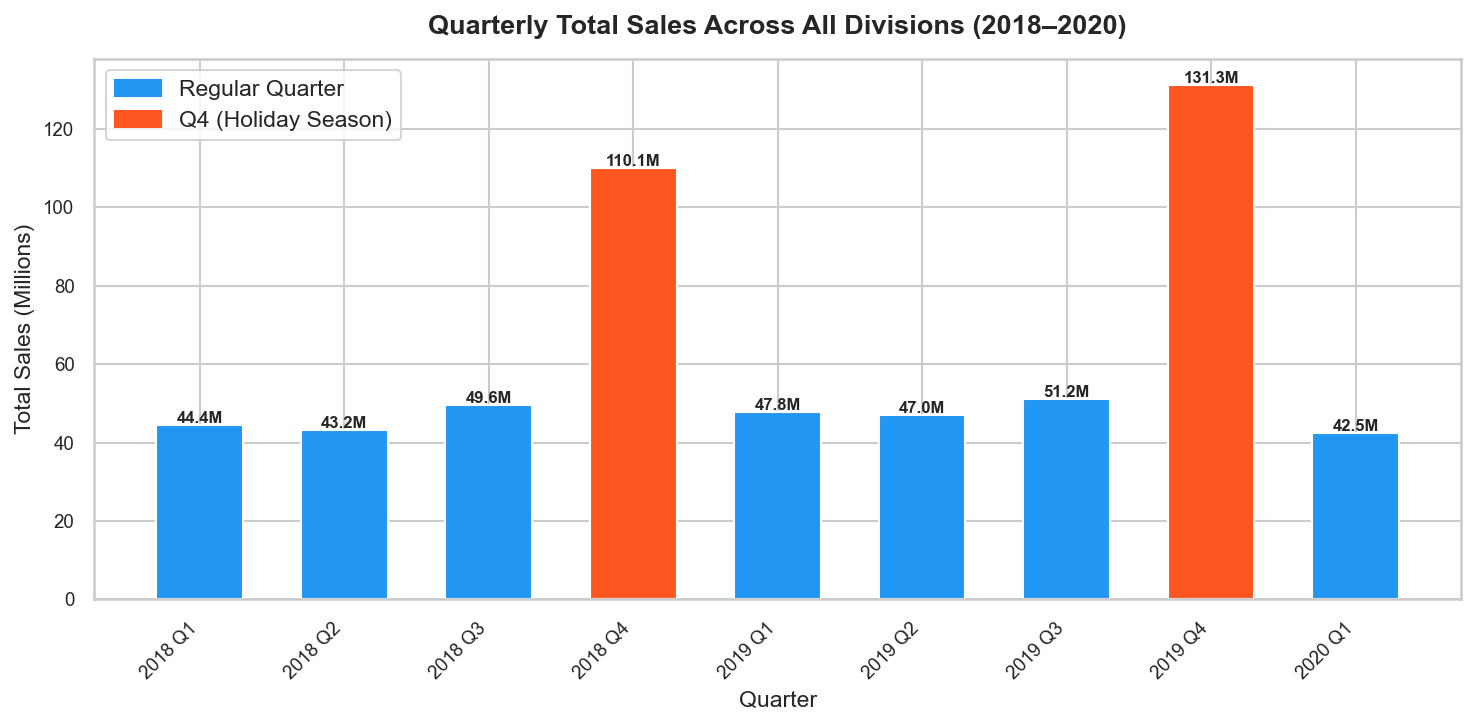

Chart 1 saved.


In [73]:
quarterly = df_viz.groupby(['year', 'quarter']).agg(total_sales=('sales', 'sum')).reset_index()
quarterly['period'] = quarterly['year'].astype(str) + ' Q' + quarterly['quarter'].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(quarterly['period'], quarterly['total_sales'] / 1e6,
              color=['#2196F3' if 'Q4' not in p else '#FF5722' for p in quarterly['period']],
              edgecolor='white', width=0.6)

for bar, val in zip(bars, quarterly['total_sales'] / 1e6):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}M', ha='center', fontsize=8, fontweight='bold')

ax.set_title("Quarterly Total Sales Across All Divisions (2018–2020)", fontweight='bold', pad=12)
ax.set_xlabel("Quarter")
ax.set_ylabel("Total Sales (Millions)")
plt.xticks(rotation=45, ha='right')

blue_patch = mpatches.Patch(color='#2196F3', label='Regular Quarter')
red_patch = mpatches.Patch(color='#FF5722', label='Q4 (Holiday Season)')
ax.legend(handles=[blue_patch, red_patch])

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}01_quarterly_sales_trend.png", bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

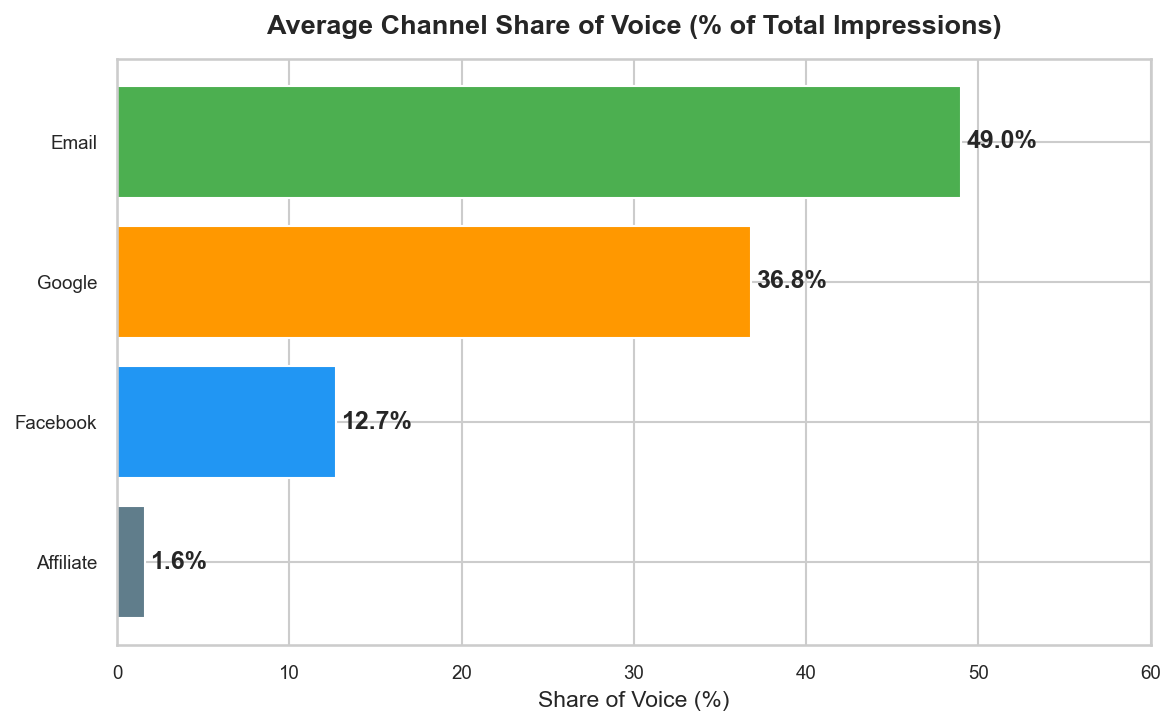

Chart 2 saved.


In [74]:
sov_data = {
    'Channel': ['Email', 'Google', 'Facebook', 'Affiliate'],
    'Avg SOV %': [49.0, 36.8, 12.7, 1.6]
}
sov_df = pd.DataFrame(sov_data).sort_values('Avg SOV %', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#607D8B', '#2196F3', '#FF9800', '#4CAF50']
bars = ax.barh(sov_df['Channel'], sov_df['Avg SOV %'], color=colors, edgecolor='white')

for bar, val in zip(bars, sov_df['Avg SOV %']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold')

ax.set_title("Average Channel Share of Voice (% of Total Impressions)", fontweight='bold', pad=12)
ax.set_xlabel("Share of Voice (%)")
ax.set_xlim(0, 60)
plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}02_channel_sov.png", bbox_inches='tight')
plt.show()
print("Chart 2 saved.")

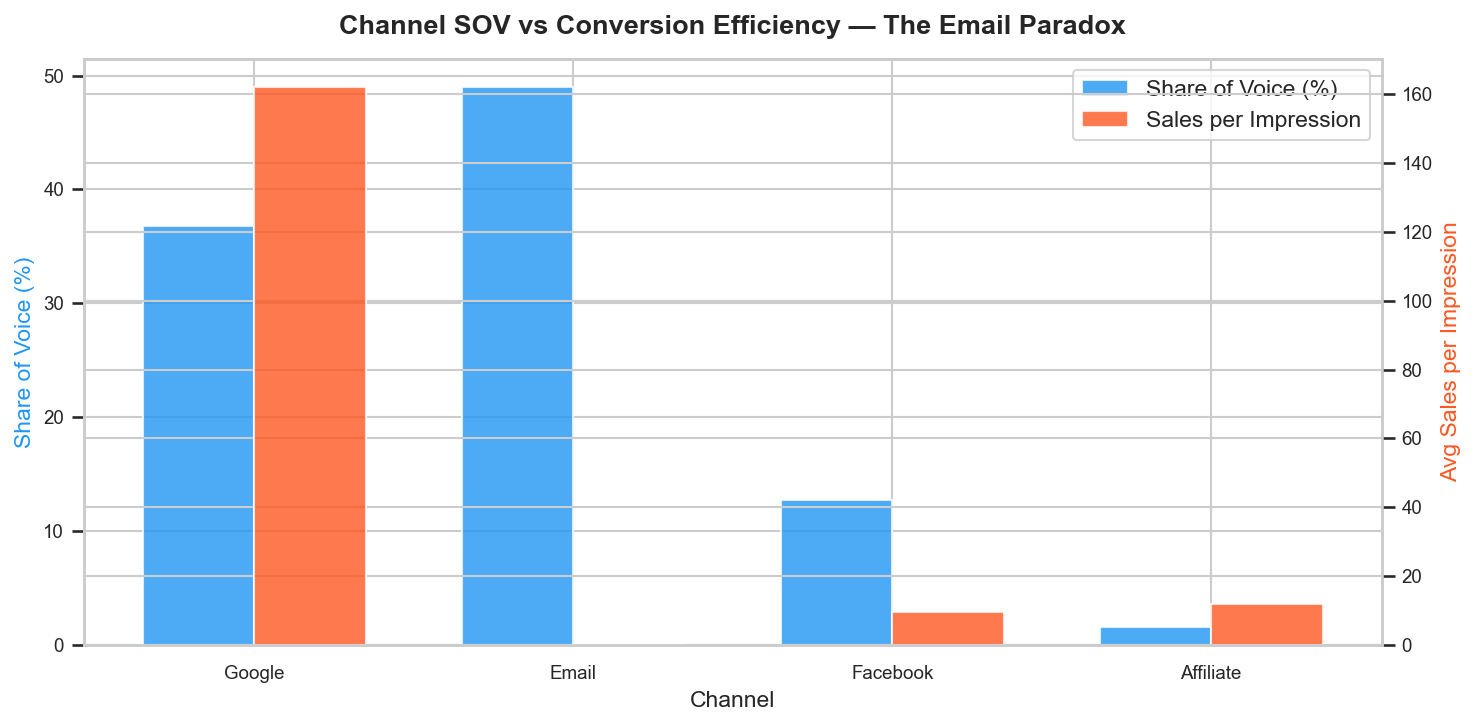

Chart 3 saved.


In [75]:
channels = ['Google', 'Email', 'Facebook', 'Affiliate']
sov = [36.8, 49.0, 12.7, 1.6]
efficiency = [162.11, 0.27, 9.43, 11.89]

x = np.arange(len(channels))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

bars1 = ax1.bar(x - width/2, sov, width, label='Share of Voice (%)',
                color='#2196F3', alpha=0.8, edgecolor='white')
bars2 = ax2.bar(x + width/2, efficiency, width, label='Sales per Impression',
                color='#FF5722', alpha=0.8, edgecolor='white')

ax1.set_xlabel("Channel")
ax1.set_ylabel("Share of Voice (%)", color='#2196F3')
ax2.set_ylabel("Avg Sales per Impression", color='#FF5722')
ax1.set_xticks(x)
ax1.set_xticklabels(channels)
ax1.set_title("Channel SOV vs Conversion Efficiency — The Email Paradox", fontweight='bold', pad=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}03_sov_vs_efficiency.png", bbox_inches='tight')
plt.show()
print("Chart 3 saved.")

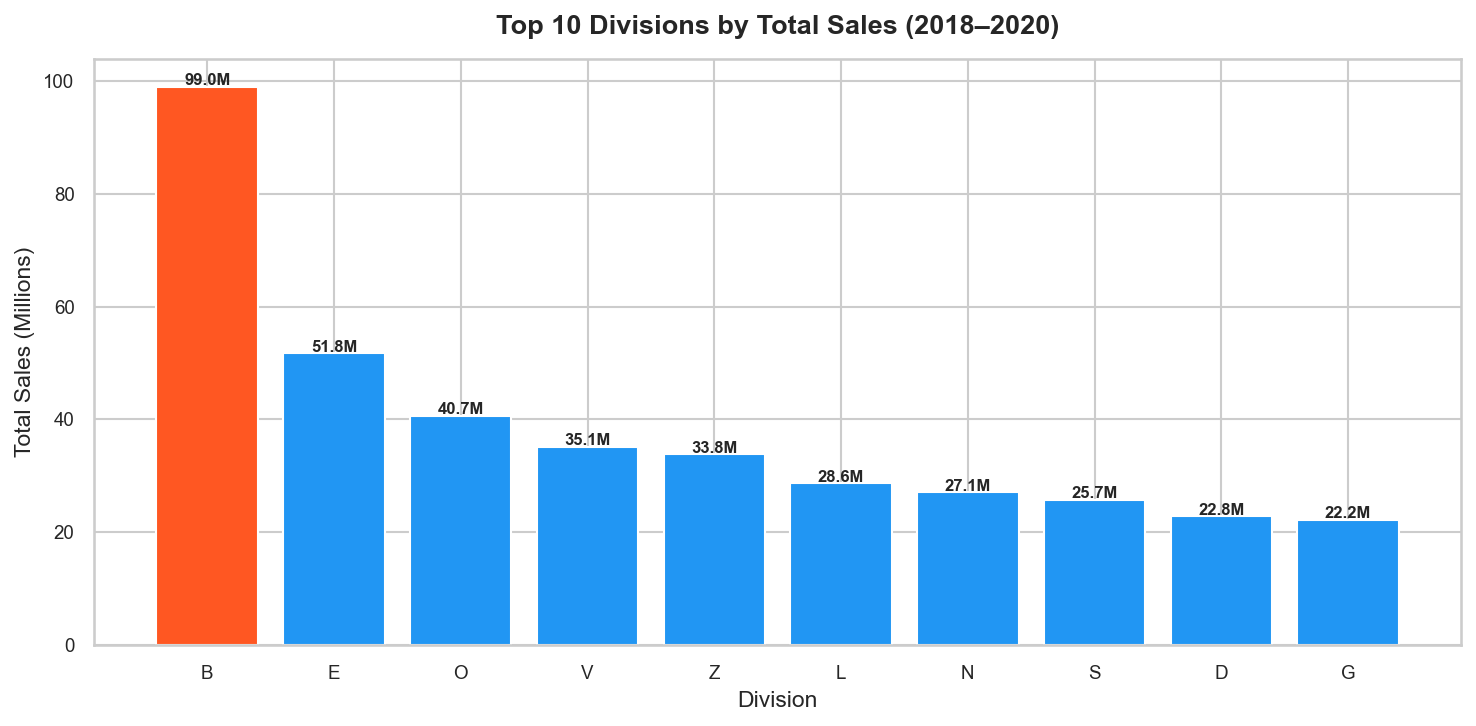

Chart 4 saved.


In [76]:
div_perf = df_viz.groupby('division').agg(
    total_sales=('sales', 'sum'),
    total_impressions=('total_impressions', 'sum')
).reset_index().sort_values('total_sales', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#FF5722' if i == 0 else '#2196F3' for i in range(len(div_perf))]
bars = ax.bar(div_perf['division'], div_perf['total_sales'] / 1e6,
              color=colors, edgecolor='white')

for bar, val in zip(bars, div_perf['total_sales'] / 1e6):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}M', ha='center', fontsize=8, fontweight='bold')

ax.set_title("Top 10 Divisions by Total Sales (2018–2020)", fontweight='bold', pad=12)
ax.set_xlabel("Division")
ax.set_ylabel("Total Sales (Millions)")
plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}04_top10_divisions.png", bbox_inches='tight')
plt.show()
print("Chart 4 saved.")

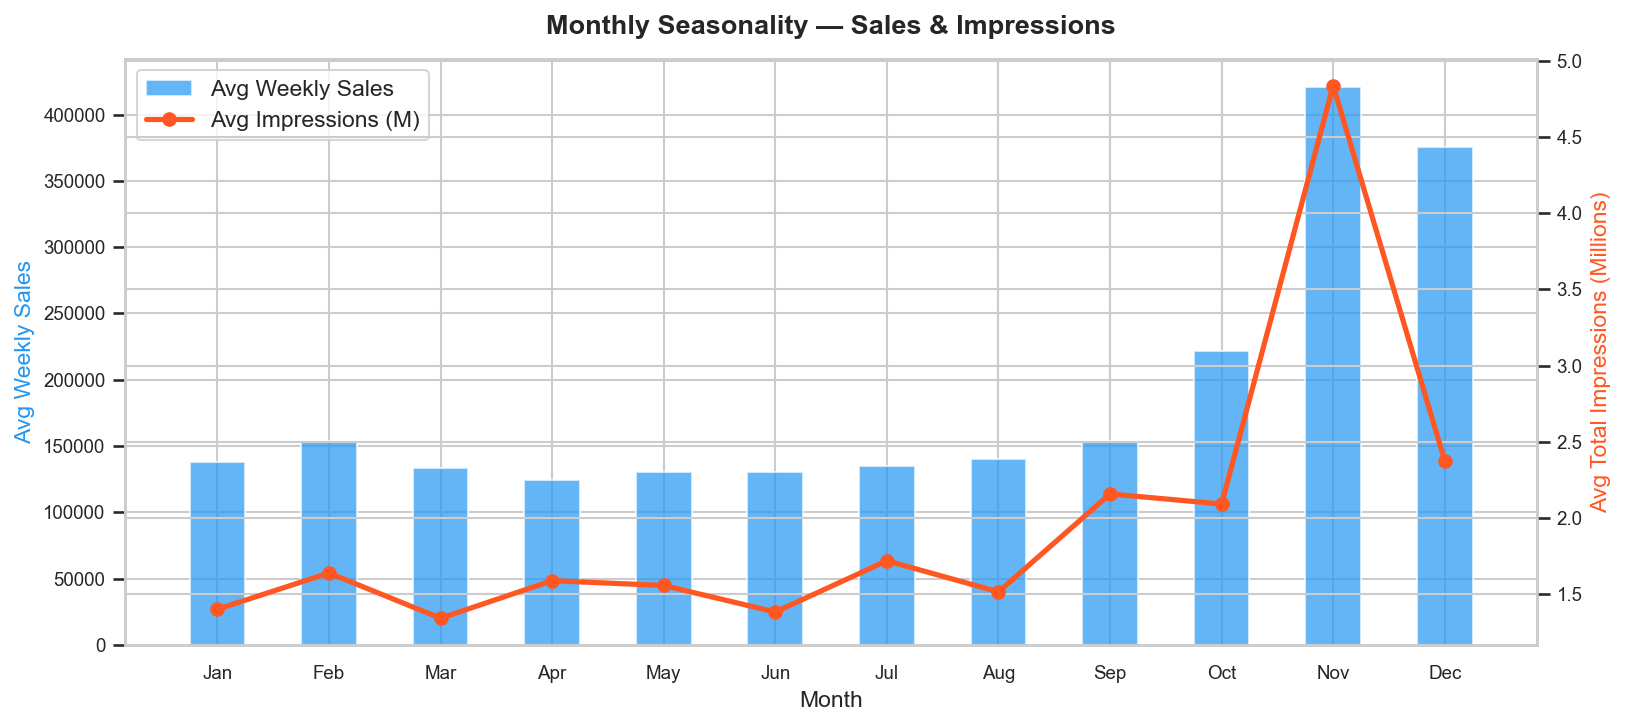

Chart 5 saved.


In [77]:
monthly = df_viz.groupby('month').agg(
    avg_sales=('sales', 'mean'),
    avg_impressions=('total_impressions', 'mean')
).reset_index()

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.bar(monthly['month'], monthly['avg_sales'], color='#2196F3',
        alpha=0.7, label='Avg Weekly Sales', width=0.5)
ax2.plot(monthly['month'], monthly['avg_impressions'] / 1e6,
         color='#FF5722', linewidth=2.5, marker='o', label='Avg Impressions (M)')

ax1.set_xticks(monthly['month'])
ax1.set_xticklabels(month_labels)
ax1.set_xlabel("Month")
ax1.set_ylabel("Avg Weekly Sales", color='#2196F3')
ax2.set_ylabel("Avg Total Impressions (Millions)", color='#FF5722')
ax1.set_title("Monthly Seasonality — Sales & Impressions", fontweight='bold', pad=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}05_monthly_seasonality.png", bbox_inches='tight')
plt.show()
print("Chart 5 saved.")

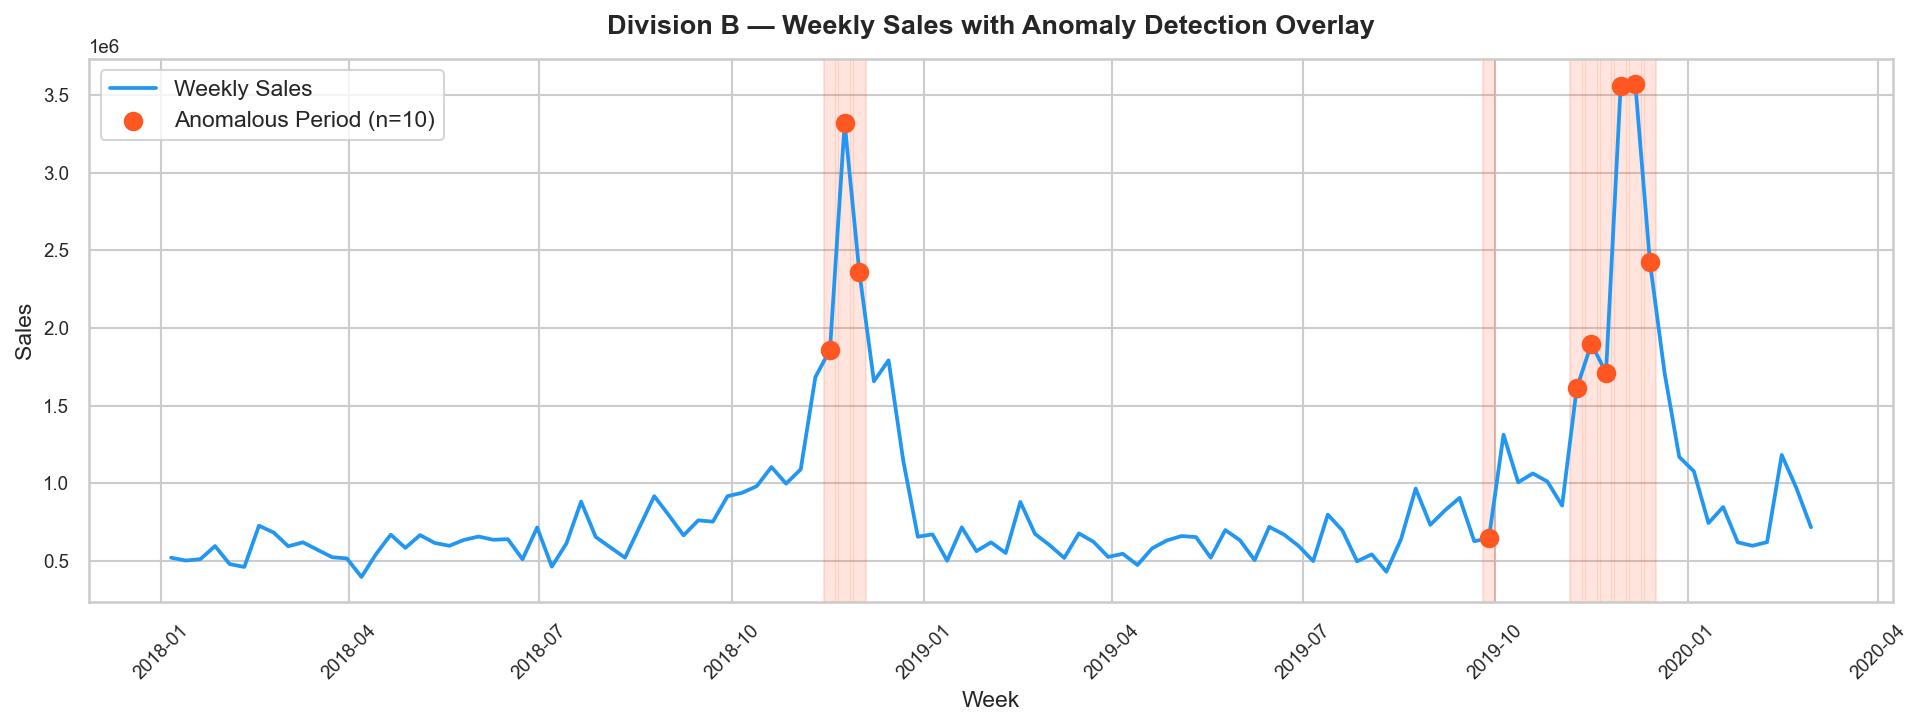

Chart 6 saved.

✓ Phase 4 complete. All charts saved.


In [78]:
# Use Division B — most interesting pattern
div_b = df_viz[df_viz['division'] == 'B'].copy()

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(div_b['calendar_week'], div_b['sales'], color='#2196F3',
        linewidth=1.8, label='Weekly Sales', zorder=2)

anomalies = div_b[div_b['is_anomaly_period'] == 1]
ax.scatter(anomalies['calendar_week'], anomalies['sales'],
           color='#FF5722', s=70, zorder=3,
           label=f'Anomalous Period (n={len(anomalies)})')

for _, row in anomalies.iterrows():
    ax.axvspan(row['calendar_week'] - pd.Timedelta(days=3),
               row['calendar_week'] + pd.Timedelta(days=3),
               alpha=0.15, color='#FF5722')

ax.set_title("Division B — Weekly Sales with Anomaly Detection Overlay", fontweight='bold', pad=12)
ax.set_xlabel("Week")
ax.set_ylabel("Sales")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}06_anomaly_overlay_divB.png", bbox_inches='tight')
plt.show()
print("Chart 6 saved.")
print("\n✓ Phase 4 complete. All charts saved.")